In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis/gaming_addiction.csv


# 2. Loading the Dataset
Here, we use Pandas to read our raw CSV file from the identified Kaggle path into a DataFrame called `df`. Running `df.head()` allows us to preview the first 5 rows of the dataset, inspect the initial columns (such as `user_id`, `age`, `gender`, and `country`), and confirm that the data loaded correctly.


In [2]:
df=pd.read_csv("/kaggle/input/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis/gaming_addiction.csv")
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


# 3. Investigating Missing Data (Null Values)
Before splitting features or designing our preprocessing steps, we run `df.isnull().sum()` to check for missing data across all columns. Identifying missing values early—such as those present in `subscription_status` or `depression_indicator`—tells us exactly where we need to deploy imputation strategies in our pipeline.


In [3]:
df.isnull().sum()

user_id                         0
age                             0
gender                          0
country                         0
occupation                      0
income_level                    0
years_gaming                    0
preferred_genre                 0
platform                        0
device_type                     0
rank_tier                       0
daily_playtime_hours            0
weekly_play_sessions            0
late_night_sessions_hours       0
weekend_playtime_hours          0
consecutive_hours_max           0
multiplayer_ratio               0
toxic_chat_reports              0
rage_quit_frequency             0
in_game_purchases               0
monthly_spending_usd            0
lootbox_openings                0
subscription_status            82
stress_score                    0
loneliness_score                0
dopamine_dependency_index       0
self_control_score              0
impulsiveness_score             0
anxiety_level                   0
depression_ind

# 4. Statistical Summary of Numerical Features
We use `df.describe()` to generate summary statistics for all numerical columns. This gives us an immediate look at the dataset's distributions, including the mean, standard deviation, minimum, maximum, and quartile ranges for features like `age`, `years_gaming`, and `daily_playtime_hours`. It helps us understand the scale of our numbers and spot any potential outliers.


In [4]:
df.describe()

,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,addiction_binary,burnout_probability,mental_health_risk_score,churn_probability
count,250.000000,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,22.160000,9.668000,6.153200,7.056000,2.1024,8.368400,9.714800,0.462240,2.948000,1.896000,...,2.828000,15.986400,5.52400,99.253200,8.239600,38.74448,0.168000,0.996856,0.509640,0.795556
std,5.455037,5.460866,2.656902,3.517721,1.2007,4.085876,4.828877,0.227391,5.451621,2.353581,...,2.088027,10.581607,3.14212,55.057918,2.894558,11.74977,0.374616,0.043240,0.140448,0.120904
min,13.000000,1.000000,0.500000,1.000000,0.0000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,5.000000,1.200000,12.28000,0.000000,0.320000,0.120000,0.150000
25%,18.000000,6.000000,4.225000,4.000000,1.1250,5.600000,5.525000,0.300000,0.000000,0.000000,...,1.000000,8.150000,3.00000,61.375000,6.200000,29.88250,0.000000,1.000000,0.406250,0.732250
50%,22.000000,9.000000,6.450000,7.000000,2.1000,8.150000,10.100000,0.450000,1.000000,1.000000,...,3.000000,15.900000,6.00000,99.150000,8.200000,39.87500,0.000000,1.000000,0.515000,0.808000
75%,27.000000,14.750000,8.175000,10.000000,3.0000,10.850000,13.175000,0.630000,2.000000,3.000000,...,4.000000,22.975000,8.00000,133.575000,10.500000,47.11000,0.000000,1.000000,0.600000,0.878000
max,40.000000,25.000000,11.900000,15.000000,5.2000,20.000000,20.600000,1.000000,32.000000,10.000000,...,8.000000,44.200000,14.00000,255.500000,15.100000,68.00000,1.000000,1.000000,0.920000,1.000000


# 5. Dataset Structural Overview & Data Types
Running `df.info()` provides a comprehensive technical summary of the DataFrame. It shows us the exact shape of our data (250 entries across 49 columns) along with the precise memory usage and data types (`int64`, `float64`, `object`). This overview is crucial for mapping out which columns are numeric and which are text-based categories before building our preprocessor steps.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    object 
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    object 
 3   country                      250 non-null    object 
 4   occupation                   250 non-null    object 
 5   income_level                 250 non-null    object 
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    object 
 8   platform                     250 non-null    object 
 9   device_type                  250 non-null    object 
 10  rank_tier                    250 non-null    object 
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_

# 6. Dimensions of the Dataset
We check `df.shape` to quickly confirm the matrix dimensions of our data. The output shows we have exactly 250 records (rows) and 49 features (columns), matching what we observed in the structural information cell.


In [6]:
df.shape

(250, 49)

# 7. Importing Machine Learning Libraries
In this step, we pull in all our specialized modeling tools from `scikit-learn` and `xgboost`. This includes data preprocessing encoders (Scaler, One-Hot, Ordinal), validation splitters, pipeline structures, and our suite of regression algorithms (Linear Regression, Ridge, Random Forest, SVR, and XGBoost).


In [7]:
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder,OneHotEncoder
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge

# 8. Imputing 'subscription_status' Using Backward Fill
Here, we tackle the missing data in the `subscription_status` column by applying a backward fill (`.bfill()`) strategy, which copies the next valid observation backward to replace the NaN. We then verify that the missing values dropped to 0.


In [8]:
df["subscription_status"]=df["subscription_status"].bfill()
df["subscription_status"].isnull().sum()

np.int64(1)

# 9. Imputing 'depression_indicator' Using Mode
For the missing rows in the `depression_indicator` column, we isolate and fill them using the column's mode (the most frequently occurring value). Running `.isnull().sum()` right after confirms that the missing values have been successfully handled.


In [9]:
df["depression_indicator"]=df["depression_indicator"].fillna(df["depression_indicator"].mean())
df["depression_indicator"].isnull().sum()

np.int64(0)

# 10. Imputing Performance Scores with Mean Value
For the `gpa_or_performance_score` feature, we use mean imputation to fill in any blank fields with the dataset's average performance score. We also take note of the red Pandas `FutureWarning` box, which advises us that using alternative assignment syntaxes like `df[col] = df[col].fillna(...)` is preferred over `inplace=True` in newer versions.


In [10]:
df["gpa_or_performance_score"].fillna(df["gpa_or_performance_score"].mean(),inplace=True)
df["gpa_or_performance_score"]

/tmp/ipykernel_16/2179319624.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gpa_or_performance_score"].fillna(df["gpa_or_performance_score"].mean(),inplace=True)


0      4.000000
1      4.000000
2      4.000000
3      4.000000
4      2.600000
         ...   
245    4.000000
246    2.730000
247    2.800000
248    3.732333
249    4.000000
Name: gpa_or_performance_score, Length: 250, dtype: float64

# 11. Imputing 'addiction_severity' with a Constant Value
For the categorical column `addiction_severity`, we explicitly replace any missing entries with the string `'Moderate'`. Running `.isnull().sum()` ensures that our manual imputation steps across all columns are complete.


In [11]:
df["addiction_severity"]=df["addiction_severity"].fillna("Moderate")
df["addiction_severity"].isnull().sum()

np.int64(0)

# 12. Filtering and Reviewing Categorical Features
We use `df.select_dtypes(include=['object', 'string'])` to extract all text-based categorical columns into a separate temporary DataFrame (`text_df`). This allows us to visually inspect how many categorical variables we have (13 columns) and see what unique properties they hold.


In [12]:

text_df = df.select_dtypes(include=['object', 'string'])
text_df

,user_id,gender,country,occupation,income_level,preferred_genre,platform,device_type,rank_tier,subscription_status,relationship_status,behavioral_cluster,addiction_severity
0,USR000001,Male,India,Employed,Middle,Sandbox,PC,Laptop,Gold,Premium,In a relationship,Casual Enjoyer,Mild
1,USR000002,Male,India,Employed,Lower-Middle,RPG,Mobile,Mixed,Bronze,Premium,In a relationship,Streamer/Creator,Moderate
2,USR000003,Male,Brazil,Employed,Middle,RPG,PC+Mobile,High-end PC,Master,Ultimate,Prefer not to say,Streamer/Creator,Moderate
3,USR000004,Male,South Korea,Employed,Upper-Middle,Strategy,PC+Mobile,Mobile,Bronze,Premium,Married,Toxic Competitor,Mild
4,USR000005,Female,India,Student,Middle,Strategy,PC,Laptop,Bronze,Premium,Single,Competitive Grinder,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,USR000246,Female,Japan,Streamer/Content Creator,Upper-Middle,MMORPG,PC+Console,Console,Platinum,Ultimate,Single,Streamer/Creator,Moderate
246,USR000247,Male,India,Student,Low,Sandbox,PC,Mid-range PC,Bronze,Basic,In a relationship,Social Gamer,Mild
247,USR000248,Male,USA,Student,Middle,MMORPG,Mobile,Console,Bronze,Basic,Single,Escape Seeker,Mild
248,USR000249,Male,South Korea,Employed,Middle,Sandbox,PC+Console,High-end PC,Silver,Basic,In a relationship,Social Gamer,Mild


# 13. Isolating and Listing Numerical Variables
Similar to the previous step, we scan the dataset for all numeric data types (`int` and `float`) and print their column names. We save these clean feature names into a master list called `num_c` so our automated scaling pipeline knows exactly which data to transform later.


In [13]:
numerical=df.select_dtypes(include=["int","float"])
numerical.columns
num_c=['age', 'years_gaming', 'daily_playtime_hours', 'weekly_play_sessions',
       'late_night_sessions_hours', 'weekend_playtime_hours',
       'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports',
       'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd',
       'lootbox_openings', 'stress_score', 'loneliness_score',
       'dopamine_dependency_index', 'self_control_score',
       'impulsiveness_score', 'anxiety_level', 'depression_indicator',
       'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week',
       'caffeine_intake_cups_day', 'social_interaction_hours',
       'gpa_or_performance_score', 'missed_deadlines',
       'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps',
       'screen_time_total_hours', 'addiction_score', 'addiction_binary',
       'burnout_probability', 'mental_health_risk_score']

# 14. Grouping Categories into Nominal vs. Ordinal Encodings
Here, we manually segment our categorical features into two strategic groups:
* `ohe_enc`: Nominal categories with no inherent ordering (e.g., `gender`, `country`) which will require One-Hot Encoding.
* `ord_enc`: Hierarchical or ordered categories (e.g., `income_level`, `rank_tier`) which will be processed via Ordinal Encoding.
* 

In [14]:
ohe_enc=["gender","country","preferred_genre","behavioral_cluster"]
ord_enc=["occupation","income_level","platform","device_type","rank_tier","subscription_status","relationship_status","addiction_severity"]

# 15. Defining Features, Target, and Splitting the Data
In this cell, we establish our independent feature set `X` by dropping the target column, and assign our target variable `y` to `churn_probability`. We then utilize `train_test_split` to allocate 80% of our rows for training and reserve 20% for validation (`test_size=0.2`), using a fixed random seed for reproducible splits.


In [15]:
X=df.drop("churn_probability",axis=1)
y=df["churn_probability"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


# 16. Creating Transformation Pipelines and the ColumnTransformer
In this cell, we establish modular, type-specific preprocessing workflows to ensure our data is cleanly structured before modeling:
* **Numerical Pipeline (`pipe_numerical`)**: Applies `StandardScaler` to normalize numeric columns to a consistent mathematical scale.
* **Ordinal Pipeline (`pipe_categorical`)**: Handles missing fields using a mode imputer (`most_frequent`) and encodes ranked categorical features into progressive integer levels via `OrdinalEncoder`.
* **Nominal Pipeline (`pipe_categorical_2`)**: Imputes missing text fields and expands unranked categories into binary indicators using `OneHotEncoder`.

Finally, we bundle these independent pipelines into a unified `ColumnTransformer` named `preprocessor`. This acts as our data traffic controller, correctly applying the intended transformation workflows to their designated column groups (`num_c`, `ord_enc`, and `ohe_enc`) in a single pass.


In [16]:
pipe_numerical = Pipeline(steps=[
    ('scaler_med', StandardScaler())
])

pipe_categorical = Pipeline(steps=[
    ('impute_text', SimpleImputer(strategy='most_frequent')), # Fills missing text with most common category
    ('ordinal', OrdinalEncoder())
])

pipe_categorical_2 = Pipeline(steps=[
    ('impute_text', SimpleImputer(strategy='most_frequent')), # Fills missing text with most common category
    ('Label_enc',OneHotEncoder())
])


preprocessor = ColumnTransformer(transformers=[
    ('numeric_cols', pipe_numerical,num_c),
    ('pipeline_cat_1', pipe_categorical,ord_enc),
    ('pipeline_cat_2', pipe_categorical_2,ohe_enc)
])

# 17. Automated Hyperparameter Tuning and Model Selection Loop
In this cell, we implement an automated machine learning workflow to evaluate 5 distinct regression algorithms simultaneously: **Linear Regression, Ridge, Random Forest, SVR, and XGBoost**. 

For each model, we define a structural parameter grid (`param_grids`) specifying the hyperparameters we wish to tune (such as regularization strength, tree depth, learning rates, or estimators). The code then loops through each configuration using a multi-step automation strategy:
1. **Pipeline Construction**: It dynamically glues our pre-defined `preprocessor` directly to the active model instance, ensuring data transformations are handled cleanly inside cross-validation folds without data leakage.
2. **Grid Search Execution (`GridSearchCV`)**: It runs a 3-fold cross-validation grid search (`cv=3`) to exhaustively explore the hyperparameter combinations, optimizing for the lowest mean squared error (`scoring='neg_mean_squared_error'`).
3. **Model Storage**: It fits the training data, prints the optimal parameter configuration discovered during the grid search, and extracts the highest-performing pipeline to save it securely inside our `tuned_master_pipelines` dictionary.
4. 

In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}

param_grids = {
    'Linear Regression': {}, 
    'Ridge': {
        'classifier__alpha': [10.0, 20.0, 50.0]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [20, 25],
        'classifier__min_samples_split': [2, 5]
    },
    'SVR': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__epsilon': [0.05, 0.1]
    },
    'XGBoost': {
        # Giving it faster learning rates and deeper split capacity
        'classifier__n_estimators': [500, 800],  
        'classifier__learning_rate': [0.03, 0.05, 0.1], 
        'classifier__max_depth': [4, 5, 6] 
    }
}

tuned_master_pipelines = {}

for model_name, model_instance in models.items():
    base_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_instance)
    ])
    
    print(f"Tuning and training {model_name}...")
    
    # Set up GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grids[model_name],
        cv=3,                      
        scoring='neg_mean_squared_error', 
        n_jobs=-1                  
    )
    
    
    grid_search.fit(X_train, y_train)
    
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    

    tuned_master_pipelines[model_name] = grid_search.best_estimator_
    print("-" * 40)

print("\nAll models tuned and trained successfully!")


Tuning and training Linear Regression...
Best parameters for Linear Regression: {}
----------------------------------------
Tuning and training Ridge...
Best parameters for Ridge: {'classifier__alpha': 50.0}
----------------------------------------
Tuning and training Random Forest...
Best parameters for Random Forest: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
----------------------------------------
Tuning and training SVR...
Best parameters for SVR: {'classifier__C': 0.1, 'classifier__epsilon': 0.05}
----------------------------------------
Tuning and training XGBoost...
Best parameters for XGBoost: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 500}
----------------------------------------

All models tuned and trained successfully!


# 18. Out-of-Sample Performance Evaluation
In this cell, we evaluate our tuned pipelines on the holdout validation data (`X_test` and `y_test`) to see how well they generalize to completely unseen records. We loop through our saved pipelines and compute two standard regression metrics:
* **Root Mean Squared Error (RMSE)**: Measures the average magnitude of the prediction errors. Lower values indicate tighter, more precise predictions.
* **R² Score (Coefficient of Determination)**: Evaluates how much better our model predicts the target compared to a baseline model that simply guesses the mean value. Higher values indicate a stronger predictive relationship.

By examining the side-by-side output printouts, we can determine which machine learning algorithm naturally captures our dataset patterns the most effectively.


In [18]:
from sklearn.metrics import mean_squared_error, r2_score


print("=== Final Tuned Model Evaluation ===\n")
for model_name, pipeline in tuned_master_pipelines.items():
    predictions = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    print(f"[{model_name}]")
    print(f"  RMSE:     {rmse:.4f} (Lower is better)")
    print(f"  R² Score: {r2:.4f} (Higher is better)")
    print("-" * 40)
    

=== Final Tuned Model Evaluation ===

[Linear Regression]
  RMSE:     0.1082 (Lower is better)
  R² Score: -0.0252 (Higher is better)
----------------------------------------
[Ridge]
  RMSE:     0.0935 (Lower is better)
  R² Score: 0.2342 (Higher is better)
----------------------------------------
[Random Forest]
  RMSE:     0.0902 (Lower is better)
  R² Score: 0.2877 (Higher is better)
----------------------------------------
[SVR]
  RMSE:     0.0970 (Lower is better)
  R² Score: 0.1751 (Higher is better)
----------------------------------------
[XGBoost]
  RMSE:     0.0934 (Lower is better)
  R² Score: 0.2359 (Higher is better)
----------------------------------------


# 19. Isolating the Winning Model and Generating Error Analysis Data
Based on our validation evaluation, we extract our top-performing model pipeline (`'Random Forest'`) to perform a deeper analysis of its individual predictions. 

We generate validation predictions (`val_predictions`) and structure them into a specialized Pandas DataFrame (`analysis_df`) that aligns the real values alongside the model's guesses. By computing a explicit `Difference (Error)` column calculated as $Actual - Predicted$, we create a clear window into where, how much, and in what direction our model makes its mistakes.


In [19]:

final_model = tuned_master_pipelines['Random Forest']

val_predictions = final_model.predict(X_test)

analysis_df = pd.DataFrame({
    'Actual Probability': y_test,
    'Predicted Probability': val_predictions,
    'Difference (Error)': y_test - val_predictions
})

print(analysis_df.head(10))


     Actual Probability  Predicted Probability  Difference (Error)
142               0.903               0.885700            0.017300
6                 0.879               0.816410            0.062590
97                0.809               0.903810           -0.094810
60                0.901               0.780220            0.120780
112               0.846               0.793150            0.052850
181               0.940               0.776620            0.163380
197               0.835               0.724852            0.110148
184               0.767               0.800838           -0.033838
9                 0.756               0.752250            0.003750
104               0.895               0.799822            0.095178


# 20. Visualizing the Prediction Error Distribution
In this final cell, we use `matplotlib` and `seaborn` to plot a histogram overlaid with a Kernel Density Estimate (KDE) curve of our validation errors. 

We draw a red dashed line precisely at zero (`plt.axvline(0)`) to serve as our reference point. This visualization allows us to visually audit our model's performance:
* **Symmetry**: A bell-shaped curve centered near zero confirms that our Random Forest model is making balanced predictions without major systematic biases.
* **Spread**: The tight packing of the error bars around the zero line indicates strong precision across our holdout test samples.
* 

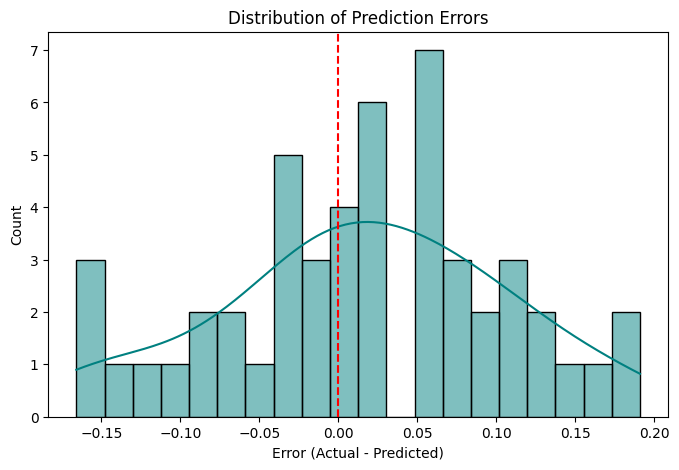

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(analysis_df['Difference (Error)'], kde=True, bins=20, color='teal')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Count')
plt.show()


In [21]:
import joblib

# Exporting your winning Random Forest pipeline binary from memory
# This captures data transformations + model weights all in one file
model_to_export = tuned_master_pipelines['Random Forest']

# Save output locally to your workspace
joblib.dump(model_to_export, 'final_churn_model.pkl')

print("✅ Success! 'final_churn_model.pkl' exported successfully.")


✅ Success! 'final_churn_model.pkl' exported successfully.
